# Classification tables for paper

## Table

### Setup

In [11]:
# imports
from dataclasses import dataclass
from __future__ import annotations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import re
from typing import Dict, List, Optional, Tuple


In [12]:
# config

OUTDIR = Path("/midtier/paetzollab/scratch/ads4015/lsm_fm_paper/tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

FOLDS = [0, 1, 2]
NTRS = [56, 105]
DECIMALS = 2

ROOTS: Dict[str, Path] = {
    "Unet Image+CLIP": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_classification_preds_super_sweep2_v3"),
    "Unet Image-only": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_classification_preds_bright_sweep_26_v3"),
    "Unet Random-init": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_classification_preds_unet_random2_v3"),
    "SwinUNETR Image+CLIP": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_classification_preds_autumn_sweep_27"),
    "SwinUNETR Image-only": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_classification_preds_expert_sweep_31"),
    "SwinUNETR Random-init": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_classification_preds_random"),
    "PCA+LR": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_classification_preds_pca_lr"),
    "ResNet": Path("/midtier/paetzollab/scratch/ads4015/temp_selma_classification_preds_resnet"),
}

MODEL_ORDER = [
    "Unet Image+CLIP",
    "SwinUNETR Image+CLIP",
    "Unet Image-only",
    "SwinUNETR Image-only",
    "Unet Random-init",
    "SwinUNETR Random-init",
    "PCA+LR",
    "ResNet",
]

# folder + file patterns
BASE_METRICS_DIR_CANDIDATES = [
    Path("cls_metrics") / "classification",
    Path("cls_metrics") / "classification_unet",
]

# naming of run directory
RUN_PATTERNS = [
    # pretrained / random / pca_lr / resnet — we only rely on cvfold + ntr being in the name
    re.compile(r"cvfold(?P<fold>\d+)_ntr(?P<ntr>\d+)(?:_|$)"),
]

# per_class_metrics filename prefixes by model family
PREFER_PREFIX = {
    "Unet Image+CLIP": "per_class_metrics_pretrained_",
    "Unet Image-only": "per_class_metrics_pretrained_",
    "SwinUNETR Image+CLIP": "per_class_metrics_pretrained_",
    "SwinUNETR Image-only": "per_class_metrics_pretrained_",
    "Unet Random-init": "per_class_metrics_random_",
    "SwinUNETR Random-init": "per_class_metrics_random_",
    "PCA+LR": "per_class_metrics_pca_lr_",
    "ResNet": "per_class_metrics_resnet_",
}

# constant for overall row in per-class metrics
OVERALL_ROW = "__OVERALL__"


### Helper functions

In [13]:
# safe mean
def safe_mean(xs: List[float]) -> float:
    xs = [x for x in xs if x is not None and np.isfinite(x)]
    return float(np.mean(xs)) if xs else float("nan")


# find run_dir for model / fold / ntr
# either <model_root>/cls_metrics/classification/ or <model_root>/cls_metrics/classification_unet/
def pick_run_dir(model_root: Path, fold: int, ntr: int) -> Optional[Path]:

    pat = re.compile(rf"cvfold{fold}_ntr{ntr}(?:_|$)")
    run_dirs: List[Path] = []

    for rel in BASE_METRICS_DIR_CANDIDATES:
        base = model_root / rel
        if not base.exists():
            continue
        run_dirs.extend([d for d in base.iterdir() if d.is_dir() and pat.search(d.name)])

    if not run_dirs:
        return None

    run_dirs.sort(key=lambda d: d.stat().st_mtime, reverse=True)
    return run_dirs[0]


# find per_class_metrics*.csv in run_dir, prefering a given prefix if provided
def find_metrics_csv(run_dir: Path, prefer_prefix: Optional[str] = None) -> Optional[Path]:

    if run_dir is None or (not run_dir.exists()):
        return None

    csvs = sorted(run_dir.glob("per_class_metrics*.csv"))
    if not csvs:
        # sometimes people nest one more folder; be robust
        csvs = sorted(run_dir.rglob("per_class_metrics*.csv"))
    if not csvs:
        return None

    if prefer_prefix:
        preferred = [p for p in csvs if p.name.startswith(prefer_prefix)]
        if preferred:
            # if multiple, choose most recent
            preferred.sort(key=lambda p: p.stat().st_mtime, reverse=True)
            return preferred[0]

    # fallback: most recent
    csvs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return csvs[0]

# parse overall ACC and MACRO_F1 from per_class_metrics CSV
def parse_overall_acc_macro_f1(csv_path: Path) -> Tuple[float, float]:

    dfm = pd.read_csv(csv_path)
    overall = dfm[dfm["class_name"] == OVERALL_ROW]
    if overall.empty:
        raise ValueError(f"No {OVERALL_ROW} row found in {csv_path}")

    row = overall.iloc[0].tolist()

    # robust parse: scan all cells and look for ACC= and MACRO_F1=
    acc = None
    macro_f1 = None
    for cell in row:
        if isinstance(cell, str):
            m1 = re.search(r"ACC\s*=\s*([0-9]*\.?[0-9]+)", cell)
            if m1:
                acc = float(m1.group(1))
            m2 = re.search(r"MACRO_F1\s*=\s*([0-9]*\.?[0-9]+)", cell)
            if m2:
                macro_f1 = float(m2.group(1))

    if acc is None or macro_f1 is None:
        raise ValueError(f"Could not parse ACC/MACRO_F1 from {csv_path}")

    return float(acc), float(macro_f1)


# evaluate model + ntr across folds — average ACC + MACRO_F1 across folds for a given model + ntr
def eval_model_ntr(model_name: str, root: Path, ntr: int) -> Dict[str, float]:
    """
    Average ACC + MACRO_F1 across folds for a given model + ntr.
    """
    accs, f1s = [], []
    for fold in FOLDS:
        run_dir = pick_run_dir(root, fold=fold, ntr=ntr)
        if run_dir is None:
            accs.append(np.nan); f1s.append(np.nan)
            continue

        csv_path = find_metrics_csv(run_dir, prefer_prefix=PREFER_PREFIX.get(model_name))
        if csv_path is None:
            accs.append(np.nan); f1s.append(np.nan)
            continue

        try:
            acc, f1 = parse_overall_acc_macro_f1(csv_path)
        except Exception:
            acc, f1 = np.nan, np.nan

        accs.append(acc)
        f1s.append(f1)

    return {"ACC": safe_mean(accs), "MACRO_F1": safe_mean(f1s)}


# bold best per column (LaTeX strings)
def latex_bold_max_per_column(df_num: pd.DataFrame, decimals: int = 2, na_rep: str = "—") -> pd.DataFrame:
    fmt = f"{{:.{decimals}f}}"
    out = pd.DataFrame(index=df_num.index, columns=df_num.columns, dtype=object)

    for col in df_num.columns:
        s = pd.to_numeric(df_num[col], errors="coerce")
        maxv = s.max(skipna=True)
        col_out = []
        for v in s.values:
            if not np.isfinite(v):
                col_out.append(na_rep)
            else:
                txt = fmt.format(float(v))
                if np.isfinite(maxv) and np.isclose(v, maxv, rtol=0, atol=1e-12):
                    txt = rf"\textbf{{{txt}}}"
                col_out.append(txt)
        out[col] = col_out
    return out


# specify LaTeX tabular colspec for n numeric columns
def latex_tabular_colspec(n_numeric_cols: int) -> str:
    return "@{}" + "l" + ("c" * n_numeric_cols) + "@{}"


# replace first tabular colspec in LaTeX string
def replace_first_tabular_colspec(latex_str: str, colspec: str) -> str:
    return re.sub(
        r"\\begin\{tabular\}\{[^}]*\}",
        rf"\\begin{{tabular}}{{{colspec}}}",
        latex_str,
        count=1,
    )


# inject formatting commands into LaTeX table string
def inject_table_formatting(
    latex_str: str,
    add_centering: bool = True,
    fontsize_cmd: str = r"\fontsize{8}{9}\selectfont",
    tabcolsep_pt: int = 2,
    arraystretch: float = 1.05,
) -> str:
    lines = latex_str.splitlines()
    out = []
    injected = False
    for line in lines:
        out.append(line)
        s = line.strip()
        if (not injected) and (s.startswith(r"\begin{table}") or s.startswith(r"\begin{sidewaystable}")):
            if add_centering:
                out.append(r"\centering")
            out.append(fontsize_cmd)
            out.append(rf"\setlength{{\tabcolsep}}{{{tabcolsep_pt}pt}}")
            out.append(rf"\renewcommand{{\arraystretch}}{{{arraystretch}}}")
            injected = True
    return "\n".join(out)


# shrink first column with your abbreviations
def _latex_wrap_model_name(name: str) -> str:
    mapping = {
        "Unet Image+CLIP": r"\makecell[l]{UNet I+T}",
        "Unet Image-only": r"\makecell[l]{UNet I}",
        "Unet Random-init": r"\makecell[l]{UNet R}",
        "SwinUNETR Image+CLIP": r"\makecell[l]{Swin I+T}",
        "SwinUNETR Image-only": r"\makecell[l]{Swin I}",
        "SwinUNETR Random-init": r"\makecell[l]{Swin R}",
        "PCA+LR": r"\makecell[l]{PCA+LR}",
        "ResNet": r"\makecell[l]{ResNet}",
    }
    return mapping.get(name, name)


### Table

In [14]:
# build table

# build DataFrame with results
records = []
for model in MODEL_ORDER:
    root = ROOTS[model]
    row = {"Model": model}
    for ntr in NTRS:
        m = eval_model_ntr(model, root, ntr=ntr)
        row[(f"samples={ntr}", "ACC")] = m["ACC"]
        row[(f"samples={ntr}", r"MACRO $F_1$")] = m["MACRO_F1"]
    records.append(row)

df_cls = pd.DataFrame.from_records(records).set_index("Model")
df_cls.columns = pd.MultiIndex.from_tuples(df_cls.columns)

# save csv
csv_out = OUTDIR / "classification_results.csv"
df_cls.round(6).to_csv(csv_out)
print(f"[Saved] {csv_out}")

# latex export with formatting
df_tex = latex_bold_max_per_column(df_cls.round(DECIMALS), decimals=DECIMALS, na_rep="—")
df_tex.index = [_latex_wrap_model_name(str(i)) for i in df_tex.index]

latex_str = df_tex.to_latex(
    escape=False,
    multicolumn=True,
    multirow=True,
    caption=(
        "Classification performance (Accuracy and Macro-F1) for few-shot (samples=56) and many-shot (samples=105). Values are averaged across 3 CV folds."
    ),
    label="tab:classification_results",
    bold_rows=False,
    longtable=False,
    index=True,
)

# Center ntr headers across ACC/MACRO_F1
# latex_str = latex_str.replace(r"\multicolumn{2}{r}{samples=24}",  r"\multicolumn{2}{c}{samples=24}")
latex_str = latex_str.replace(r"\multicolumn{2}{r}{samples=56}",  r"\multicolumn{2}{c}{Few-shot}")
latex_str = latex_str.replace(r"\multicolumn{2}{r}{samples=105}", r"\multicolumn{2}{c}{Many-shot}")

# tight colspec: Model + (3 ntr blocks * 2 metrics) = 6 numeric cols
latex_str = replace_first_tabular_colspec(latex_str, latex_tabular_colspec(n_numeric_cols=6))

# inject formatting (for compactness)
latex_str = inject_table_formatting(
    latex_str,
    add_centering=True,
    fontsize_cmd=r"\fontsize{8}{9}\selectfont",
    tabcolsep_pt=3,
    arraystretch=1.1,
)

# save tex
tex_out = OUTDIR / "classification_results.tex"
tex_out.write_text(latex_str)
print(f"[Saved] {tex_out}")

# display in notebook
display(df_cls.round(DECIMALS))


[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/tables/classification_results.csv
[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/tables/classification_results.tex


samples=56             samples=105            
                             ACC MACRO $F_1$         ACC MACRO $F_1$
Model                                                               
Unet Image+CLIP             0.61        0.57        0.74        0.69
SwinUNETR Image+CLIP        0.40        0.35        0.65        0.61
Unet Image-only             0.71        0.69        0.62        0.58
SwinUNETR Image-only        0.51        0.46        0.53        0.48
Unet Random-init            0.49        0.46        0.61        0.57
SwinUNETR Random-init       0.40        0.33        0.47        0.44
PCA+LR                      0.33        0.28        0.47        0.40
ResNet                      0.36        0.27        0.49        0.43

### Plot

### Setup

In [15]:
# config
FIG_OUTDIR = Path("/midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs")
FIG_OUTDIR.mkdir(parents=True, exist_ok=True)

NTR_MIN, NTR_MAX = 56, 105 # inclusive
METRIC_KEY = "MACRO_F1" # configurable: "MACRO_F1" or "ACC"

# models to include (configurable) and in this order
PLOT_MODELS = [
    "Unet Image+CLIP",
    "Unet Image-only",
    "Unet Random-init",
    "ResNet",
    "PCA+LR",
]

# style + label mapping (configurable)
PLOT_STYLE = {
    "Unet Image+CLIP":   dict(label="UNet I+T",         color="deepskyblue",            ls="-"),
    "Unet Image-only":   dict(label="UNet I",           color="orange",                 ls="-"),
    "Unet Random-init":  dict(label="UNet S",           color="red",                    ls="-"),
    "ResNet":            dict(label="ResNet",           color="chocolate",              ls="-"),
    "PCA+LR":            dict(label="PCA+LR",           color="gray",                   ls="-"),
}

# Figure geometry
FIGSIZE = (5.2, 3.2)   # wider so lines are readable
LINEWIDTH = 2.0
DOT_SIZE = 28

# For nice vector PDF text embedding (good for LNCS/MICCAI)
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


### Helper functions

In [16]:
# function to get metric values (acc, macro f1) for one model, fold, ntr
def eval_model_fold_ntr(model_name: str, root: Path, fold: int, ntr: int) -> dict:
    run_dir = pick_run_dir(root, fold=fold, ntr=ntr)
    if run_dir is None:
        return {"ACC": np.nan, "MACRO_F1": np.nan}

    csv_path = find_metrics_csv(run_dir, prefer_prefix=PREFER_PREFIX.get(model_name))
    if csv_path is None:
        return {"ACC": np.nan, "MACRO_F1": np.nan}

    try:
        acc, f1 = parse_overall_acc_macro_f1(csv_path)
    except Exception:
        acc, f1 = np.nan, np.nan

    return {"ACC": float(acc), "MACRO_F1": float(f1)}


# collect all points across folds and ntr range (one point per fold, ntr)
def collect_points_long(
    models: list,
    *,
    ntr_min: int,
    ntr_max: int,
    metric_key: str,
) -> pd.DataFrame:
    rows = []
    for model_name in models:
        root = ROOTS[model_name]
        for ntr in range(ntr_min, ntr_max + 1):
            for fold in FOLDS:
                m = eval_model_fold_ntr(model_name, root, fold=fold, ntr=ntr)
                val = m.get(metric_key, np.nan)
                rows.append({
                    "model": model_name,
                    "fold": fold,
                    "ntr": int(ntr),
                    metric_key: float(val) if val is not None else np.nan,
                })
    df = pd.DataFrame(rows)
    return df


# plot (dots and best fit line per model)
def plot_metric_vs_train_size(
    df_long: pd.DataFrame,
    *,
    metric_key: str,
    models_in_order: list,
    style_map: dict,
    ntr_min: int,
    ntr_max: int,
    outdir: Path,
    figsize=(9.4, 4.0),
    show: bool = True,
):
    fig, ax = plt.subplots(figsize=figsize)

    for model_name in models_in_order:
        if model_name not in style_map:
            continue

        st = style_map[model_name]
        label = st["label"]
        color = st["color"]
        ls = st["ls"]

        sub = df_long[df_long["model"] == model_name].copy()
        sub = sub[np.isfinite(sub[metric_key].to_numpy())]

        if sub.empty:
            # still add legend handle so ordering remains visible if desired
            ax.plot([], [], color=color, linestyle=ls, linewidth=LINEWIDTH, label=label)
            continue

        x = sub["ntr"].to_numpy(dtype=float)
        y = sub[metric_key].to_numpy(dtype=float)

        # points: all dots
        ax.scatter(x, y, s=DOT_SIZE, color=color, alpha=0.75)

        # best-fit line across ALL points (folds + ntr)
        if len(x) >= 2:
            a, b = np.polyfit(x, y, deg=1)
            xx = np.linspace(ntr_min, ntr_max, 200)
            yy = a * xx + b
            ax.plot(xx, yy, color=color, linestyle=ls, linewidth=LINEWIDTH, label=label, alpha=0.55)
        else:
            ax.plot([], [], color=color, linestyle=ls, linewidth=LINEWIDTH, label=label, alpha=0.55)

    # labels
    nice_metric = "Macro F1" if metric_key.upper() == "MACRO_F1" else metric_key
    # ax.set_title(f"Classification: {nice_metric} vs. Train Size")
    ax.set_xlabel("Num train samples", fontsize=14)
    ax.set_ylabel(nice_metric, fontsize=14)

    ax.set_xlim(53, 107)
    ax.set_xticks(range(55, 106, 5))  # show every 5 ticks 55..105
    ax.set_yticks(np.arange(0.2, 0.81, 0.2))  # show every 0.1 ticks from 0 to 1
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, linewidth=0.3, alpha=0.4)

    # # legend
    # ax.legend(
    #     loc="center left",
    #     bbox_to_anchor=(1.02, 0.5),
    #     frameon=False,
    # )

    fig.tight_layout()

    # save
    metric_tag = metric_key.lower().replace(" ", "_")
    pdf_path = outdir / f"classification_figure.pdf"
    png_path = outdir / f"classification_figure.png"
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"[Saved] {pdf_path}")
    print(f"[Saved] {png_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/classification_avg_macro_f1_56-105.csv
[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/classification_figure.pdf
[Saved] /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/classification_figure.png


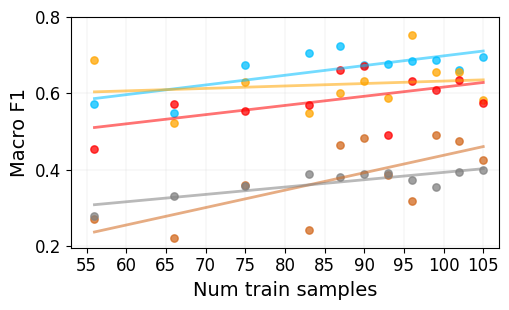

In [17]:
# run 

# create df of points
df_pts = collect_points_long(
    PLOT_MODELS,
    ntr_min=NTR_MIN,
    ntr_max=NTR_MAX,
    metric_key=METRIC_KEY,
)

# average across folds to get 1 point per ntr
df_avg = (
    df_pts.groupby(["model", "ntr"], as_index=False)[METRIC_KEY]
          .mean()
)

# save the averaged table used for plotting
avg_csv = FIG_OUTDIR / f"classification_avg_{METRIC_KEY.lower()}_{NTR_MIN}-{NTR_MAX}.csv"
df_avg.to_csv(avg_csv, index=False)
print(f"[Saved] {avg_csv}")

_ = plot_metric_vs_train_size(
    df_avg, 
    metric_key=METRIC_KEY,
    models_in_order=PLOT_MODELS,
    style_map=PLOT_STYLE,
    ntr_min=NTR_MIN,
    ntr_max=NTR_MAX,
    outdir=FIG_OUTDIR,
    figsize=FIGSIZE,
    show=True,
)
